# Efficiency and Fairness in Order Dispatch Under Demand Shock

## Abstract

This project looks at a dispatch problem in a small ride-hailing style simulator. The question is whether a policy can handle a sudden demand surge in one zone without making driver income much more unequal. That is a real issue in dispatch systems: sending everyone to the busy area can look efficient in the short run, but it can also leave some drivers with fewer completed orders. I model the system with `6` zones, `60` drivers, and `40` decision steps per episode. I compare two simple baselines, `Local-First` and `Demand-Greedy`, with a PPO policy trained with the reward `completion_rate - alpha * gini`. The demand data is synthetic, which makes the experiment easier to control and repeat across random seeds. In the shock setting, PPO gives a much lower final income `Gini` than `Local-First`, while the drop in revenue is not statistically clear in the saved multi-seed tests. The alpha sweep is less decisive: with only `5` seeds and `20k` training steps, it would be too strong to claim that one value of `alpha` is best. The main takeaway is more modest. A learned dispatch rule can reduce income inequality in this simulator, but the reward weight and the simulator design still need more testing.


## Problem Setup

The project asks: **under a local demand shock, can PPO improve driver income fairness while keeping most of the platform's order completion performance?** I use a small simulator rather than a real platform dataset, so the aim is not to reproduce a full ride-hailing system. The aim is to build a clean RL problem where the efficiency-fairness trade-off is visible.

The setup is:

- Number of zones: `6`
- Number of drivers: `60`
- Decision steps per episode: `40`
- Base demand intensity: `[4, 6, 5, 7, 4, 5]`
- Shocked zone: zone `4` (zero-based index `3`)
- Shock window: steps `15` to `24`
- Final calibrated shock level: `5`
- Main PPO setting: `alpha = 0.2`, with checks for `alpha in {0.0, 0.1, 0.2, 0.4}`

### Data Source and Generation

The demand data is synthetic. In the `normal` scene, each zone's demand at each step is drawn from a Poisson distribution with rates `base_lambda = [4, 6, 5, 7, 4, 5]`. In the `shock` scene, zone `3` gets multiplied demand during steps `15-24`. This gives a repeatable stress test where one area becomes more attractive for a short period. I use synthetic Poisson demand because it lets the experiment control the shock zone, shock window, and shock multiplier directly, so the difference between `normal` and `shock` comes from a clear experimental intervention rather than confounding structure in real platform logs.

The shock level is fixed at `5` after checking the baseline behaviour. I wanted the shock to be large enough to change the dispatch problem, but not so large that all policies fail for obvious reasons. The main experiment uses `5` random seeds: `0, 42, 123, 456, 789`. That is enough for means, standard deviations, error bars, and a small set of significance tests, but it is still a small experiment.

Synthetic data is a limitation. Real dispatch logs would include travel time, distance, cancellations, pricing, and driver preferences. Those details would make the project more realistic, but also much harder to finish cleanly. The simplified data generator keeps the experiment reproducible and lets the report focus on the RL design. The results should therefore be read as controlled simulator evidence from a stress test, not as a direct operational claim about a real ride-hailing platform.

### Gym-Style RL Formulation and Observability

The simulator is a finite-horizon Gym-style reinforcement learning environment. Strictly speaking, the policy observes an aggregated state rather than the full simulator state: the environment keeps each driver's cumulative income internally for the fairness reward, while the policy observation exposes only driver counts, current demand, normalized time, previous Gini, and the shock flag. I therefore describe it as a partially observed control problem using an MDP-like formulation:

- Observation `O_t`: driver counts by zone, current demand by zone, normalized time `t / T`, previous income `Gini`, and a flag for the shock window.
- Hidden simulator state: individual driver zones, cumulative driver incomes, the current demand schedule, and the current time step.
- Action `A_t`: a flattened `36`-dimensional logits vector. The environment reshapes it into a `6 x 6` matrix and applies a row-wise softmax, so each source zone gets a probability distribution over destination zones.
- Transition: drivers move according to the sampled destinations. A driver only earns income if they are selected to match local demand in the destination zone.
- Reward `R_t`: `completion_rate - alpha * gini`, where `gini` is computed from the hidden cumulative driver-income vector. The first term pays for fulfilled demand; the second term penalizes unequal cumulative driver income.
- Horizon `T`: each episode ends after `40` steps.
- Discount factor `γ`: PPO uses the default `stable-baselines3` value `γ = 0.99`.

The `normal` and `shock` scenes use the same observation, action, reward, and termination rules. Only the demand process changes.


## Environment

The environment is implemented as a Gymnasium/OpenAI Gym-style `FairDispatchEnv`: it provides `reset` and `step`, and defines continuous `Box` observation and action spaces so that it can be used directly with `stable-baselines3` PPO.

At each step, the environment returns a `15`-dimensional observation vector:

- `available_drivers_by_zone[6]`
- `current_demand_by_zone[6]`
- normalized time step `t / T`
- previous-step Gini coefficient
- shock-window flag

The action is a flattened `36`-dimensional vector. The environment reshapes it into a `6 x 6` matrix and applies a row-wise softmax. Each row then says where drivers from one source zone should try to go.

A completed order adds `1` to platform revenue and `1` to that driver's income. If too many drivers go to the same destination, the environment randomly chooses which drivers get matched, up to the local demand. This is where the fairness problem comes from. A hotspot can produce many orders, but it can also concentrate income among the drivers who reach it at the right time.


In [1]:
# Minimal simulator used by the notebook. It follows the same logic as the src/ package.
from __future__ import annotations
from dataclasses import dataclass
from typing import Any
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

@dataclass(frozen=True)
class DispatchConfig:
    """Keep the simulator size and shock settings in one place."""

    zone_count: int = 6
    driver_count: int = 60
    horizon: int = 40
    base_lambda: tuple[int, ...] = (4, 6, 5, 7, 4, 5)
    initial_drivers: tuple[int, ...] = (8, 12, 10, 13, 8, 9)
    shock_zone: int = 3
    shock_start: int = 15
    shock_end: int = 24
    shock_multiplier: int = 3
    promoted_shock_multiplier: int = 5
    alpha_grid: tuple[float, ...] = (0.0, 0.1, 0.2, 0.4)
    primary_alpha: float = 0.2

    def __post_init__(self) -> None:
        if self.zone_count != len(self.base_lambda):
            raise ValueError('zone_count must match base_lambda length')
        if self.zone_count != len(self.initial_drivers):
            raise ValueError('zone_count must match initial_drivers length')
        if self.driver_count != sum(self.initial_drivers):
            raise ValueError('driver_count must equal sum(initial_drivers)')

DEFAULT_CONFIG = DispatchConfig()

def gini_coefficient(values: np.ndarray) -> float:
    """Closer to 0 means incomes are more equal."""

    ordered = np.sort(np.asarray(values, dtype=float))
    if ordered.size == 0:
        return 0.0
    total = ordered.sum()
    if total <= 0.0:
        return 0.0
    count = ordered.size
    weighted_sum = np.dot(np.arange(1, count + 1, dtype=float), ordered)
    gini = (2.0 * weighted_sum) / (count * total) - (count + 1) / count
    return float(max(0.0, min(1.0, gini)))

def bottom_percent_mean(values: np.ndarray, *, share: float = 0.2) -> float:
    incomes = np.sort(np.asarray(values, dtype=float))
    if incomes.size == 0:
        return 0.0
    if not 0.0 < share <= 1.0:
        raise ValueError('share must be in (0, 1]')
    cutoff = max(1, math.ceil(incomes.size * share))
    return float(np.mean(incomes[:cutoff]))

def bottom20_income_mean(values: np.ndarray) -> float:
    return bottom_percent_mean(values, share=0.2)

def local_first_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """Stay local when there is demand, otherwise spread to active zones."""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    active = np.flatnonzero(demand_by_zone > 0)
    if active.size == 0:
        active = np.arange(zone_count)
    for zone_idx in range(zone_count):
        if demand_by_zone[zone_idx] > 0:
            matrix[zone_idx, zone_idx] = 1.0
        else:
            matrix[zone_idx, active] = 1.0 / active.size
    return matrix

def demand_greedy_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """Very plain greedy rule: everyone goes to the busiest zone."""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    target_zone = int(np.argmax(demand_by_zone))
    matrix[:, target_zone] = 1.0
    return matrix

def probabilities_to_logits(matrix: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(matrix, dtype=np.float32), 1e-12, 1.0)
    return np.log(clipped).reshape(-1).astype(np.float32)

def build_normal_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.poisson(lam=np.asarray(config.base_lambda, dtype=float), size=(config.horizon, config.zone_count)).astype(np.int32)

def build_shock_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    demands = build_normal_demand_schedule(config=config, seed=seed)
    multiplier = shock_multiplier or config.shock_multiplier
    demands[config.shock_start : config.shock_end + 1, config.shock_zone] *= multiplier
    return demands

def sample_episode_demands(config: DispatchConfig = DEFAULT_CONFIG, *, scene: str = 'normal', seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    if scene == 'normal':
        return build_normal_demand_schedule(config=config, seed=seed)
    if scene == 'shock':
        return build_shock_demand_schedule(config=config, seed=seed, shock_multiplier=shock_multiplier)
    raise ValueError(f'Unsupported scene: {scene}')

def shock_flag_for_step(step_index: int, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal') -> float:
    if scene != 'shock':
        return 0.0
    return float(config.shock_start <= step_index <= config.shock_end)

try:
    import gymnasium as gym
    from gymnasium import spaces
except ImportError:
    class _FallbackEnv:
        pass
    @dataclass
    class _FallbackBox:
        low: Any
        high: Any
        shape: tuple[int, ...]
        dtype: Any
    class _FallbackSpaces:
        Box = _FallbackBox
    class _FallbackGym:
        Env = _FallbackEnv
    gym = _FallbackGym()
    spaces = _FallbackSpaces()

class FairDispatchEnv(gym.Env):
    """Small zone-level dispatch env used by both PPO and the baselines."""

    metadata = {'render_modes': []}
    def __init__(self, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal', alpha: float | None = None, shock_multiplier: int | None = None, seed: int | None = None, demand_schedule: np.ndarray | None = None) -> None:
        self.config = config
        self.scene = scene
        self.alpha = config.primary_alpha if alpha is None else alpha
        self.shock_multiplier = shock_multiplier or config.shock_multiplier
        self.seed = seed
        self._provided_demand_schedule = None if demand_schedule is None else np.asarray(demand_schedule, dtype=np.int32)
        self.observation_space = spaces.Box(low=0.0, high=np.inf, shape=(15,), dtype=np.float32)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(config.zone_count * config.zone_count,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.episode_demands = np.zeros((config.horizon, config.zone_count), dtype=np.int32)
        self.driver_zones = np.zeros(config.driver_count, dtype=np.int32)
        self.cumulative_income = np.zeros(config.driver_count, dtype=np.float32)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        """Start a new episode and return the first observation."""

        if seed is not None:
            self.rng = np.random.default_rng(seed)
        elif self.seed is not None:
            self.rng = np.random.default_rng(self.seed)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0
        self.driver_zones = np.concatenate([np.full(count, zone_idx, dtype=np.int32) for zone_idx, count in enumerate(self.config.initial_drivers)])
        self.cumulative_income = np.zeros(self.config.driver_count, dtype=np.float32)
        self.episode_demands = self._provided_demand_schedule.copy() if self._provided_demand_schedule is not None else sample_episode_demands(self.config, scene=self.scene, seed=self.seed if seed is None else seed, shock_multiplier=self.shock_multiplier)
        info = self._info(fulfilled_orders=0, completion_rate=0.0, step_revenue=0.0)
        return self._observation(), info

    def action_logits_to_matrix(self, action: np.ndarray) -> np.ndarray:
        logits = np.asarray(action, dtype=np.float32).reshape(self.config.zone_count, self.config.zone_count)
        logits = logits - logits.max(axis=1, keepdims=True)
        weights = np.exp(logits)
        return weights / weights.sum(axis=1, keepdims=True)

    @property
    def available_drivers_by_zone(self) -> np.ndarray:
        return np.bincount(self.driver_zones, minlength=self.config.zone_count).astype(np.float32)

    def _current_demand(self) -> np.ndarray:
        if self.current_step >= self.config.horizon:
            return np.zeros(self.config.zone_count, dtype=np.float32)
        return self.episode_demands[self.current_step].astype(np.float32)

    def _observation(self) -> np.ndarray:
        return np.concatenate([
            self.available_drivers_by_zone,
            self._current_demand(),
            np.array([
                self.current_step / self.config.horizon,
                self.previous_gini,
                shock_flag_for_step(self.current_step, config=self.config, scene=self.scene),
            ], dtype=np.float32),
        ]).astype(np.float32)

    def _info(self, *, fulfilled_orders: int, completion_rate: float, step_revenue: float) -> dict[str, float]:
        return {
            'fulfilled_orders': float(fulfilled_orders),
            'completion_rate': float(completion_rate),
            'step_revenue': float(step_revenue),
            'episode_revenue': float(self.episode_revenue),
            'current_gini': float(gini_coefficient(self.cumulative_income)),
            'bottom20_income_mean': float(bottom20_income_mean(self.cumulative_income)),
        }

    def step(self, action: np.ndarray):
        """Move drivers, match orders, then compute this step's reward."""

        if self.current_step >= self.config.horizon:
            raise RuntimeError('Episode already terminated. Call reset().')
        demand = self.episode_demands[self.current_step].copy()
        allocation = self.action_logits_to_matrix(action)
        assignments = {zone_idx: [] for zone_idx in range(self.config.zone_count)}
        source_zones = self.driver_zones.copy()
        for zone_idx in range(self.config.zone_count):
            driver_indices = np.flatnonzero(source_zones == zone_idx)
            if driver_indices.size == 0:
                continue
            destinations = self.rng.choice(self.config.zone_count, size=driver_indices.size, p=allocation[zone_idx])
            for driver_index, destination in zip(driver_indices, destinations):
                assignments[int(destination)].append((int(driver_index), zone_idx))
        fulfilled_orders = 0
        updated_zones = source_zones.copy()
        for destination_zone, assigned_drivers in assignments.items():
            max_matches = min(len(assigned_drivers), int(demand[destination_zone]))
            if max_matches == 0:
                continue
            chosen = self.rng.choice(len(assigned_drivers), size=max_matches, replace=False)
            for local_idx in np.asarray(chosen, dtype=int):
                driver_index, _source_zone = assigned_drivers[local_idx]
                updated_zones[driver_index] = destination_zone
                self.cumulative_income[driver_index] += 1.0
                fulfilled_orders += 1
        self.driver_zones = updated_zones
        self.episode_revenue += float(fulfilled_orders)
        current_gini = gini_coefficient(self.cumulative_income)
        completion_rate = fulfilled_orders / max(1, int(demand.sum()))
        reward = float(completion_rate - self.alpha * current_gini)
        self.previous_gini = current_gini
        self.current_step += 1
        terminated = self.current_step >= self.config.horizon
        info = self._info(fulfilled_orders=fulfilled_orders, completion_rate=completion_rate, step_revenue=float(fulfilled_orders))
        return self._observation(), reward, terminated, False, info

def evaluate_baseline(policy_name: str, scene: str, *, seed: int = 0, alpha: float = DEFAULT_CONFIG.primary_alpha, shock_multiplier: int | None = None):
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        demand = observation[DEFAULT_CONFIG.zone_count : DEFAULT_CONFIG.zone_count * 2]
        available = observation[: DEFAULT_CONFIG.zone_count]
        if policy_name == 'Local-First':
            action = probabilities_to_logits(local_first_policy(available, demand))
        elif policy_name == 'Demand-Greedy':
            action = probabilities_to_logits(demand_greedy_policy(available, demand))
        else:
            raise ValueError(f'Unsupported baseline: {policy_name}')
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': policy_name,
        'scene': scene,
        'alpha': np.nan,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()

def _load_ppo():
    try:
        from stable_baselines3 import PPO
    except ImportError as exc:
        raise RuntimeError('Install stable-baselines3 to use PPO in this notebook') from exc
    return PPO

def train_and_evaluate_ppo(*, alpha: float, scene: str, total_timesteps: int = 20000, seed: int = 0, shock_multiplier: int = DEFAULT_CONFIG.promoted_shock_multiplier):
    PPO = _load_ppo()
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    model = PPO('MlpPolicy', env, verbose=0, seed=seed)
    model.learn(total_timesteps=total_timesteps)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        action, _ = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': 'PPO',
        'scene': scene,
        'alpha': alpha,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()


## Baselines and PPO

I compare three policies:

1. `Local-First`: drivers serve demand in their current zone when possible. If their zone has no demand, they spread across zones that do.
2. `Demand-Greedy`: all drivers are sent toward the zone with the highest current demand. This is intentionally crude, and it is useful as a sanity check.
3. `PPO`: a learned stochastic policy trained in the same environment with the fairness-aware reward.

The notebook includes the environment, metrics, baselines, and PPO helper code. The larger batch runs are saved in CSV files so that the report does not need to retrain the model every time it is opened.

### Why PPO

PPO fits this version of the problem because the action is continuous. The policy outputs a `6 x 6` matrix of logits, not a single discrete action. Tabular Q-learning would not fit this state-action space. A DQN-style approach would need a discretised action set, and a useful discretisation of all possible dispatch matrices would become awkward fast.

PPO is not the only possible choice. A constrained RL method or a more specialised dispatch algorithm might do better. I use PPO here because it is a standard policy-gradient method, works with continuous actions, and is available in `stable-baselines3`.


## Metrics

I use four metrics:

- `episode_revenue`: total completed orders in the episode. Since each order has value `1`, this is also total platform revenue.
- `mean_completion_rate`: average fraction of demand fulfilled at each step.
- `final_episode_gini`: Gini coefficient of cumulative driver income at the end of the episode. Lower is more equal.
- `bottom20_income_mean`: mean income of the lowest-earning 20% of drivers.

The main comparison is `PPO(alpha=0.2)` against `Local-First`, since `Local-First` is the stronger baseline. `Demand-Greedy` stays in the tables because it shows how badly a naive hotspot rule can behave. The evaluation reports mean and standard deviation over `5` seeds. The plots use error bars, and the main comparisons include two-sample `t`-tests and Cohen's `d`.


## Results

The table reports the multi-seed results (`n = 5`, seeds `0, 42, 123, 456, 789`). Values are `mean ± standard deviation`.

| Algorithm | Scene | episode_revenue | final_episode_gini | bottom20_income_mean |
| --- | --- | ---: | ---: | ---: |
| Local-First | normal | 1234.6±29.2 | 0.0995±0.0154 | 15.60±1.40 |
| PPO (`alpha=0.2`) | normal | 1205.0±36.8 | 0.0914±0.0108 | 15.50±0.99 |
| Demand-Greedy | normal | 352.4±6.4 | 0.2008±0.0144 | 3.12±0.30 |
| Local-First | shock | 1282.4±36.2 | 0.1166±0.0158 | 15.55±1.00 |
| PPO (`alpha=0.2`) | shock | 1241.4±36.7 | 0.0781±0.0084 | 16.60±0.81 |
| Demand-Greedy | shock | 622.0±37.2 | 0.1314±0.0130 | 7.05±0.70 |

The shock scene is the most useful comparison. `PPO(alpha=0.2)` earns `1241.4` revenue compared with `1282.4` for `Local-First`. The difference is negative, but the saved significance table gives `p = 0.1134`, so I would not call this a clear revenue loss. For fairness, the difference is much stronger. PPO has final `Gini = 0.0781`, compared with `0.1166` for `Local-First` (`p = 0.0013`, Cohen's `d = -3.05`). The bottom-20% income measure also moves in the same direction: `16.60` for PPO and `15.55` for `Local-First`.

The alpha sweep in the shock scene is:

| alpha | episode_revenue | final_episode_gini | bottom20_income_mean |
| ---: | ---: | ---: | ---: |
| 0.0 | 1239.6±29.2 | 0.0856±0.0082 | 16.17±0.79 |
| 0.1 | 1240.0±34.3 | 0.0844±0.0049 | 16.03±0.59 |
| 0.2 | 1241.4±36.7 | 0.0781±0.0084 | 16.60±0.81 |
| 0.4 | 1232.0±36.6 | 0.0778±0.0079 | 16.72±0.49 |

The alpha sweep should be read cautiously. The differences between PPO alpha values are smaller than the seed-to-seed variation, so I do not claim that `alpha=0.2` is globally optimal. I use `alpha=0.2` as the main setting because it is the pre-specified fairness-aware setting and gives a clear comparison with the two baselines.


In [2]:
# Load per-run experiment results and aggregate mean/std summaries
import json
runs_df = pd.read_csv('results/multi_seed_results.csv')
summary_df = (
    runs_df.groupby(['algorithm', 'scene', 'alpha'], dropna=False)
    .agg(
        revenue_mean=('episode_revenue', 'mean'),
        revenue_std=('episode_revenue', 'std'),
        gini_mean=('final_episode_gini', 'mean'),
        gini_std=('final_episode_gini', 'std'),
        bottom20_mean=('final_episode_bottom20_income_mean', 'mean'),
        bottom20_std=('final_episode_bottom20_income_mean', 'std'),
    )
    .reset_index()
)
significance_df = pd.read_csv('results/significance_tests.csv')


def format_mean_std(row: pd.Series, mean_col: str, std_col: str, digits: int) -> str:
    return f"{row[mean_col]:.{digits}f}±{row[std_col]:.{digits}f}"


# Build the baseline table (mean ± std)
baseline_records = []
for algo in ['Local-First', 'Demand-Greedy']:
    for scene in ['normal', 'shock']:
        row = summary_df[(summary_df['algorithm'] == algo) & (summary_df['scene'] == scene)].iloc[0]
        baseline_records.append({
            'algorithm': algo,
            'scene': scene,
            'alpha': np.nan,
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# Build the PPO table (mean ± std)
ppo_records = []
for alpha in [0.0, 0.1, 0.2, 0.4]:
    for scene in ['normal', 'shock']:
        row = summary_df[
            (summary_df['algorithm'] == 'PPO')
            & (summary_df['scene'] == scene)
            & (summary_df['alpha'].round(1) == alpha)
        ].iloc[0]
        ppo_records.append({
            'algorithm': 'PPO',
            'scene': scene,
            'alpha': alpha,
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# Load the saved one-run shock income samples for the CDF plot
baseline_shock_income_df = pd.read_csv('results/baseline_shock_incomes.csv')
ppo_shock_income_df = pd.read_csv('results/ppo_shock_incomes.csv')
ppo_shock_income_df = ppo_shock_income_df[
    (ppo_shock_income_df['scene'] == 'shock')
    & (ppo_shock_income_df['alpha'].astype(float).round(1) == 0.2)
]
shock_income_samples = {
    label: group.sort_values('driver_index')['income'].astype(float).tolist()
    for label, group in baseline_shock_income_df.groupby('algorithm')
}
shock_income_samples['PPO (alpha=0.2)'] = (
    ppo_shock_income_df.sort_values('driver_index')['income'].astype(float).tolist()
)

with open('results/shock_calibration.json', 'r', encoding='utf-8') as handle:
    shock_calibration = json.load(handle)

# Build display tables
baseline_df = pd.DataFrame(baseline_records)
ppo_df = pd.DataFrame(ppo_records)
main_results = pd.concat([baseline_df, ppo_df[ppo_df['alpha'] == 0.2]], ignore_index=True)
main_results['sort_key'] = main_results.apply(
    lambda row: {
        ('normal', 'Local-First'): 0,
        ('normal', 'PPO'): 1,
        ('normal', 'Demand-Greedy'): 2,
        ('shock', 'Local-First'): 3,
        ('shock', 'PPO'): 4,
        ('shock', 'Demand-Greedy'): 5,
    }[(row['scene'], row['algorithm'])],
    axis=1,
)
main_results = main_results.sort_values('sort_key').drop(columns='sort_key').reset_index(drop=True)
alpha_tradeoff_df = ppo_df[ppo_df['scene'] == 'shock'].sort_values('alpha').reset_index(drop=True)
shock_main_comparison = significance_df[
    (significance_df['scene'] == 'shock') & (significance_df['comparison'] == 'PPO(α=0.2) vs Local-First')
].copy()
shock_main_comparison['metric'] = shock_main_comparison['metric'].replace({
    '平台收入': 'Platform revenue',
    '基尼系数': 'Gini coefficient',
})

print('Frozen calibrated shock level:', shock_calibration['frozen_multiplier'])
print()
print('Main results (multi-seed, n=5):')
display(main_results[['algorithm', 'scene', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('PPO alpha sweep in the shock scene:')
display(alpha_tradeoff_df[['alpha', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('Significance tests for PPO(alpha=0.2) vs Local-First in the shock scene:')
display(shock_main_comparison[['metric', 'p_value', 'cohens_d', 'significant']])


Frozen calibrated shock level: 5

Main results (multi-seed, n=5):


,algorithm,scene,episode_revenue,final_episode_gini,bottom20_income_mean
0,Local-First,normal,1234.6±29.2,0.0995±0.0154,15.60±1.40
1,PPO,normal,1205.0±36.8,0.0914±0.0108,15.50±0.99
2,Demand-Greedy,normal,352.4±6.4,0.2008±0.0144,3.12±0.30
3,Local-First,shock,1282.4±36.2,0.1166±0.0158,15.55±1.00
4,PPO,shock,1241.4±36.7,0.0781±0.0084,16.60±0.81
5,Demand-Greedy,shock,622.0±37.2,0.1314±0.0130,7.05±0.70



PPO alpha sweep in the shock scene:


,alpha,episode_revenue,final_episode_gini,bottom20_income_mean
0,0.0,1239.6±29.2,0.0856±0.0082,16.17±0.79
1,0.1,1240.0±34.3,0.0844±0.0049,16.03±0.59
2,0.2,1241.4±36.7,0.0781±0.0084,16.60±0.81
3,0.4,1232.0±36.6,0.0778±0.0079,16.72±0.49



Significance tests for PPO(alpha=0.2) vs Local-First in the shock scene:


,metric,p_value,cohens_d,significant
4,Platform revenue,0.113433,-1.124005,No
5,Gini coefficient,0.001322,-3.048115,Yes


## Figure Results

The code below rebuilds four figures from the saved CSV files:

- `episode_revenue_by_scene.png`
- `final_gini_by_scene.png`
- `shock_income_cdf.png`
- `alpha_tradeoff.png`

The batch experiments were run in `Google Colab`. This notebook reads the saved `results/` files instead of retraining PPO. The bar charts show mean values with error bars. The CDF plot shows the driver income distribution in the shock scene, and the alpha plot shows the PPO revenue-Gini trade-off.


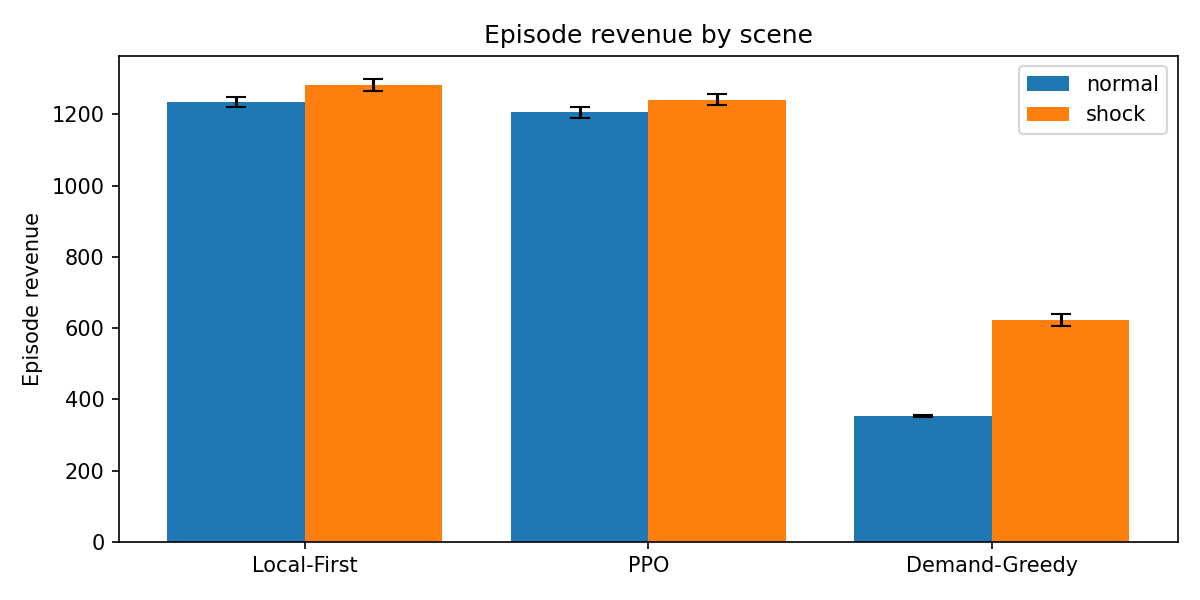

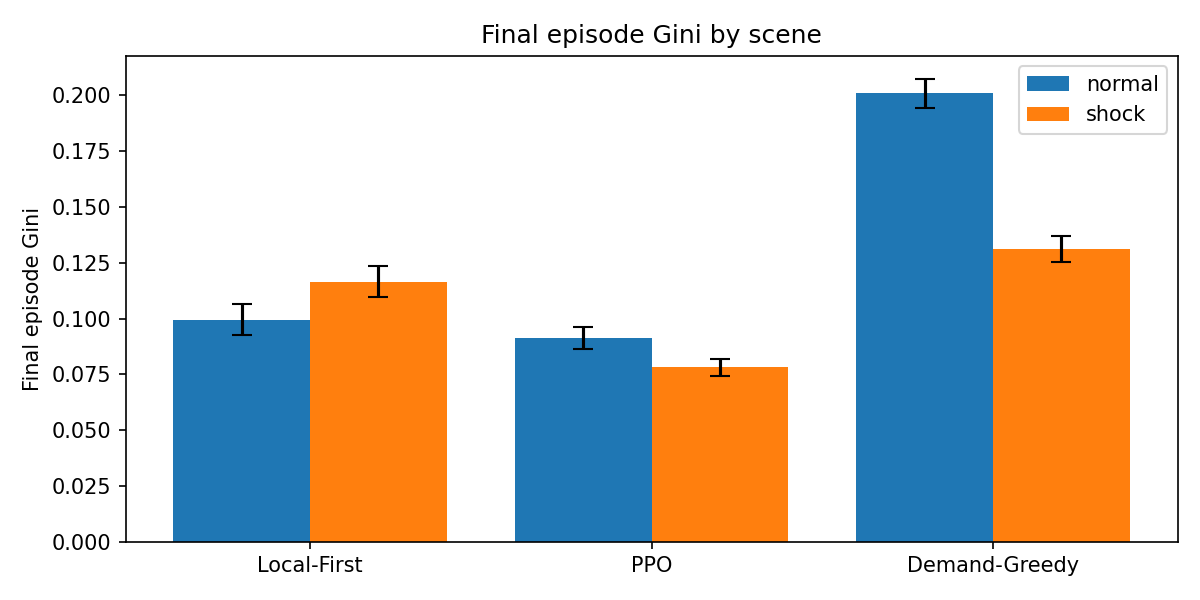

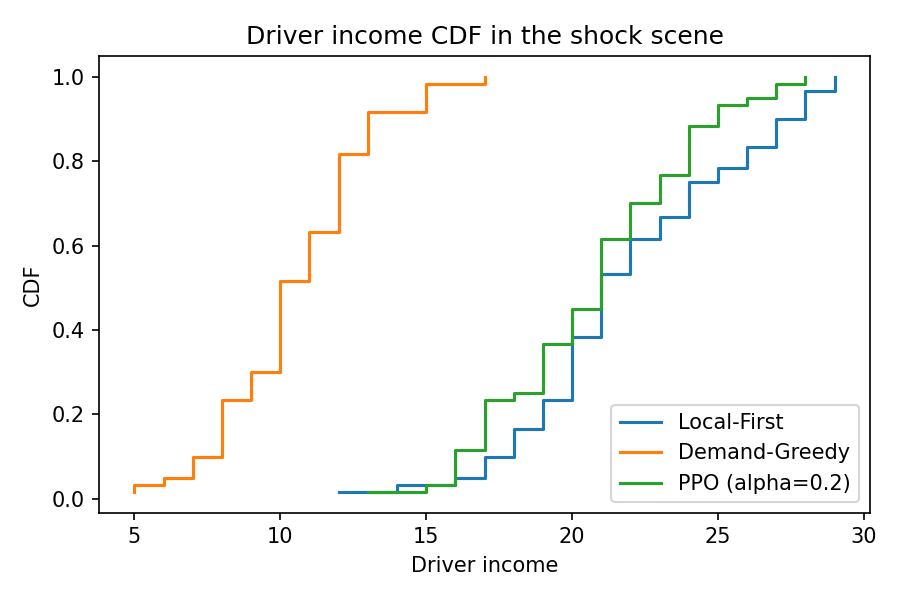

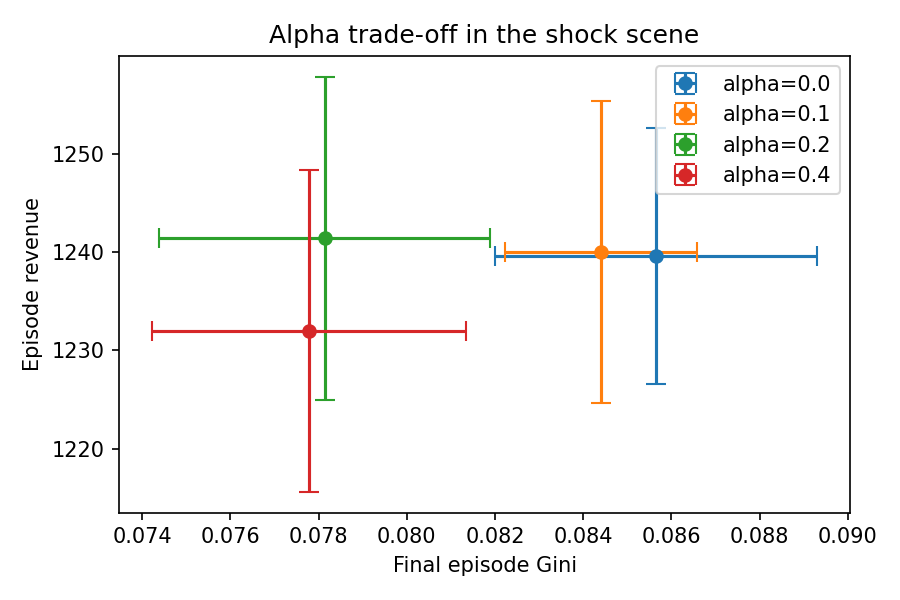

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

EXPORT_DIR = Path('figures')
EXPORT_DIR.mkdir(exist_ok=True)

# Load summary stats for error bars
stats_df = pd.read_csv('results/statistical_summary.csv')

# Figure 1: episode revenue by scene
algorithms = ['Local-First', 'Demand-Greedy', 'PPO']
normal_rev_mean = []
normal_rev_std = []
shock_rev_mean = []
shock_rev_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_rev_mean.append(normal_row['revenue_mean'].values[0])
    normal_rev_std.append(normal_row['revenue_std'].values[0])
    shock_rev_mean.append(shock_row['revenue_mean'].values[0])
    shock_rev_std.append(shock_row['revenue_std'].values[0])

positions = np.arange(len(algorithms))
plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_rev_mean, width=0.4, yerr=normal_rev_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_rev_mean, width=0.4, yerr=shock_rev_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Episode revenue')
plt.title('Episode revenue by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'episode_revenue_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 2: final episode Gini by scene
normal_gini_mean = []
normal_gini_std = []
shock_gini_mean = []
shock_gini_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_gini_mean.append(normal_row['gini_mean'].values[0])
    normal_gini_std.append(normal_row['gini_std'].values[0])
    shock_gini_mean.append(shock_row['gini_mean'].values[0])
    shock_gini_std.append(shock_row['gini_std'].values[0])

plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_gini_mean, width=0.4, yerr=normal_gini_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_gini_mean, width=0.4, yerr=shock_gini_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Final episode Gini')
plt.title('Final episode Gini by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'final_gini_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 3: driver income CDF in the shock scene
plt.figure(figsize=(6, 4))
for label, values in shock_income_samples.items():
    sorted_values = sorted(values)
    y_values = [(idx + 1) / len(sorted_values) for idx in range(len(sorted_values))]
    plt.step(sorted_values, y_values, where='post', label=label)
plt.xlabel('Driver income')
plt.ylabel('CDF')
plt.title('Driver income CDF in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'shock_income_cdf.png', dpi=150)
plt.show()
plt.close()

# Figure 4: alpha trade-off in the shock scene
ppo_shock_df = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock')].sort_values('alpha')
plt.figure(figsize=(6, 4))
for _, row in ppo_shock_df.iterrows():
    plt.errorbar(row['gini_mean'], row['revenue_mean'], 
                 xerr=row['gini_std'], yerr=row['revenue_std'],
                 fmt='o', capsize=5, label=f"alpha={row['alpha']}")
plt.xlabel('Final episode Gini')
plt.ylabel('Episode revenue')
plt.title('Alpha trade-off in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'alpha_tradeoff.png', dpi=150)
plt.show()
plt.close()


## Conclusion

In this simulator, PPO improves driver-income fairness under a demand shock. Compared with `Local-First`, `PPO(alpha=0.2)` has a lower final `Gini` in the shock scene: `0.0781` versus `0.1166`, and the saved test is statistically significant (`p = 0.0013`, Cohen's `d = -3.05`). Revenue is lower on average: `1241.4` versus `1282.4`, but the difference is not significant at the 5% level (`p = 0.1134`). That is the main result: the learned policy improves fairness here without a clear collapse in order completion.

The alpha analysis does not give a strong tuning conclusion. Several alpha settings are close to each other, so I would not say that `alpha=0.2` is optimal. A safer interpretation is that PPO is useful in this setting, while the exact reward weight would need more tuning.

The main limitation is that the environment is still simplified and the policy faces a partially observed state. The fairness reward uses the full cumulative driver-income vector internally, but the PPO policy only observes aggregate zone counts and the previous Gini. I also do not model a real road network, travel times, driver rejection, dynamic pricing, or long-term driver preferences. A stronger follow-up would use an order-level simulator or real platform data and test whether the fairness improvement remains under richer operational constraints.


## References

1. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). [Proximal policy optimization algorithms](https://arxiv.org/abs/1707.06347). arXiv:1707.06347.

2. Xu, Z., Li, Z., Guan, Q., Zhang, D., Li, Q., Nan, J., Liu, C., Bian, W., & Ye, J. (2018). [Large-scale order dispatch in on-demand ride-hailing platforms: A learning and planning approach](https://www.kdd.org/kdd2018/accepted-papers/view/large-scale-order-dispatch-in-on-demand-ride-sharing-platforms-a-learning-a). Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 905-913.

3. Tang, X., Qin, Z., Zhang, F., Wang, Z., Xu, Z., Ma, Y., Zhu, H., & Ye, J. (2019). [A deep value-network based approach for multi-driver order dispatching](https://kdd.org/kdd2019/accepted-papers/view/a-deep-value-network-based-approach-for-multi-driver-order-dispatching). Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining.

4. Sun, J., Jin, H., Yang, Z., Su, L., & Wang, X. (2022). [Optimizing long-term efficiency and fairness in ride-hailing via joint order dispatching and driver repositioning](https://engineering.purdue.edu/~lusu/papers/KDD2022.pdf). Proceedings of the 28th ACM SIGKDD Conference on Knowledge Discovery and Data Mining.

5. Liang, Y. (2024). [Fairness-aware dynamic ride-hailing matching based on reinforcement learning](https://www.mdpi.com/2079-9292/13/4/775). Electronics, 13(4), 775.

6. Shi, C., Wang, X., Luo, S., Zhu, H., Ye, J., & Song, R. (2023). [Dynamic causal effects evaluation in A/B testing with a reinforcement learning framework](https://www.tandfonline.com/doi/abs/10.1080/01621459.2022.2027776). Journal of the American Statistical Association, 118(543), 2059-2071.


## Reproducibility and How to Run

The batch experiments were mainly run in `Google Colab`. This notebook reads saved result files by default instead of retraining PPO when opened, which makes the report faster to review and avoids hardware-dependent training time during marking. The tables and figures use:

- `results/multi_seed_results.csv`
- `results/statistical_summary.csv`
- `results/significance_tests.csv`
- `results/baseline_shock_incomes.csv`
- `results/ppo_shock_incomes.csv`

To regenerate the results from scratch, install the dependencies in `requirements.txt`, or use the Colab workflow in `docs/COLAB使用指南.md`, then run these commands from this folder:

1. `pip install -q -r requirements.txt`
2. `python scripts/evaluate_baselines.py`
3. `python scripts/train_ppo.py --seed 0 --total-timesteps 20000`
4. `python scripts/run_multi_seed_experiments.py --total-timesteps 20000`
5. `python scripts/statistical_analysis.py`

These scripts rebuild the CSV summaries in `results/` and the four figures in `figures/`. Keeping training separate from the report makes the final notebook self-contained, readable, and easier to reproduce.


## Group Contribution Statement

This was a four-person group project. Fill in the final names and contribution percentages before submission.

**Group members**: [fill before submission]

**Contribution percentages**: [fill before submission]

Main work covered environment design, baseline policies, PPO training, multi-seed experiments, statistical tests, figures, and notebook writing.
